<a href="https://colab.research.google.com/github/robsonfagner/peso_e_altura/blob/main/Class_h_m.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
url = "https://raw.githubusercontent.com/robsonfagner/peso_e_altura/refs/heads/main/weight-height.csv"
df_weight = pd.read_csv(url)


In [15]:
df_weight.head()

,Height,Weight,Gender,Age,BMI,Weight_Category,Activity_Level,Systolic_BP,Diastolic_BP,BP_Category,Cholesterol,Cholesterol_Category,Smoker
0,161.72,53.80,Female,19,20.57,Normal,Sedentary,140,90,High,150,Normal,No
1,171.99,76.12,Male,56,25.73,Overweight,Lightly Active,122,73,Elevated,192,Normal,No
2,179.51,87.38,Male,69,27.12,Overweight,Sedentary,126,97,High,231,Borderline,No
3,179.68,74.28,Male,20,23.01,Normal,Very Active,102,71,Normal,235,Borderline,No
4,162.94,62.76,Female,54,23.64,Normal,Lightly Active,126,60,Elevated,249,High,No


In [16]:
len(df_weight)

50000

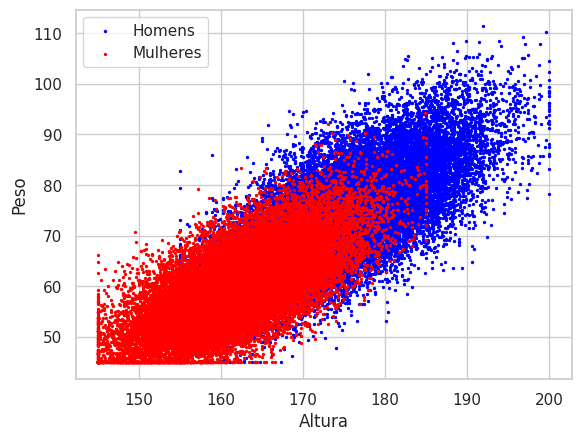

In [17]:
homens = df_weight[(df_weight['Gender']=="Male")]
mulheres = df_weight[(df_weight['Gender']=="Female")]


# Mostrar o gráfico com os registros masculinos com a cor azul
plt.scatter(
    homens['Height'], # Eixo X
    homens['Weight'], # Eixo Y
    c='blue',         # Cor Azul (c = color = cor)
    s = 2,            # Tamanho do ponto (s = size = tamanho)
    label='Homens')   # Etiqueta que vai aparecer na legenda do gráfico


plt.scatter(mulheres['Height'],mulheres['Weight'],c='red', s = 2, label='Mulheres')


plt.xlabel('Altura')   # Título de eixo X
plt.ylabel('Peso')     # Título do eixo Y

# Limites dos valores para cada eixo
#plt.xlim(xmin=100, xmax=250)
#plt.ylim(ymin=20, ymax=130)

# Mostra a legenda
plt.legend()

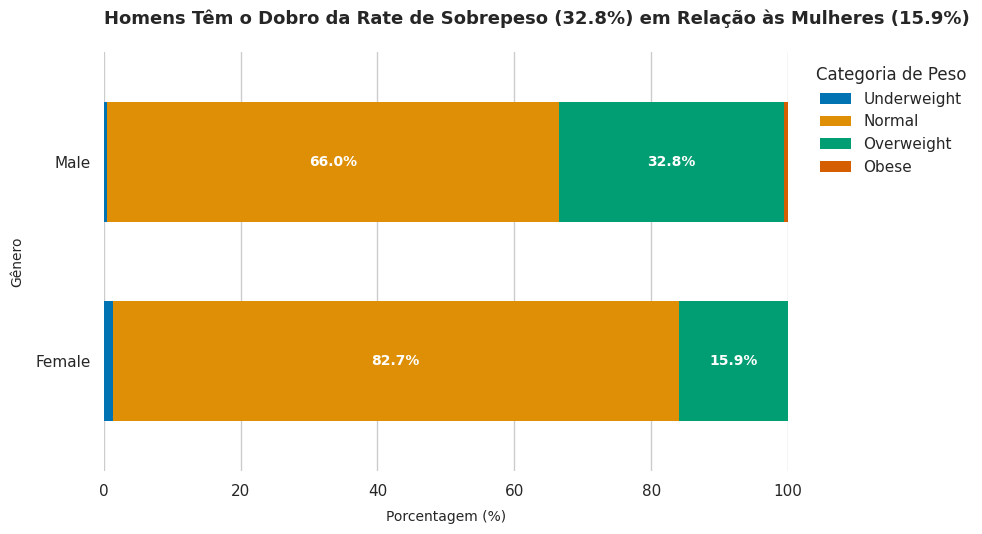

In [18]:
# 1. Configurar o estilo visual (Seaborn aplica isso automaticamente ao Matplotlib)
sns.set_theme(style='whitegrid', palette='colorblind')


# 3. Definir a ordem desejada para as categorias de peso
category_order = ['Underweight', 'Normal', 'Overweight', 'Obese']

# 4. Criar a tabela de porcentagens cruzadas entre Gênero e Categoria de Peso
# O 'normalize="index"' garante que cada barra de gênero some 100%
ct = pd.colab_ct = pd.crosstab(df_weight['Gender'], df_weight['Weight_Category'], normalize='index') * 100
ct = ct[category_order]

# 5. Desenhar o gráfico de barras horizontais empilhadas
fig, ax = plt.subplots(figsize=(10, 5.5))
colors = sns.color_palette('colorblind', 4)
ct.plot(kind='barh', stacked=True, color=colors, ax=ax, edgecolor='none', width=0.6)

# 6. Adicionar os textos de porcentagem no meio de cada bloco
for p in ax.patches:
    width = p.get_width()
    if width > 3:  # Só adiciona texto se o bloco for largo o suficiente para não amassar
        x = p.get_x() + width / 2
        y = p.get_y() + p.get_height() / 2
        ax.annotate(f'{width:.1f}%',
                    (x, y),
                    ha='center',
                    va='center',
                    color='white',
                    fontweight='bold',
                    fontsize=10)

# 7. Títulos e rótulos limpos e profissionais
ax.set_title('Homens Têm o Dobro da Rate de Sobrepeso (32.8%) em Relação às Mulheres (15.9%)',
             fontsize=13, fontweight='bold', pad=20, loc='left')
ax.set_xlabel('Porcentagem (%)', fontsize=10, labelpad=8)
ax.set_ylabel('Gênero', fontsize=10, labelpad=8)
ax.set_xlim(0, 100)

# Posicionar a legenda fora do gráfico para não obstruir os dados
ax.legend(title='Categoria de Peso', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

# Remover as linhas pretas externas (spines) para dar um visual moderno e "clean"
sns.despine(left=True, bottom=True)

# Ajustar o espaçamento automático das margens
plt.tight_layout()

# Exibir o gráfico no Colab
plt.show()